# <p style="text-align:center;">Extracting Moloch data from the DataPlatform</p>

<p style="text-align:center;">
Weather Services @a2a </br>
06/02/2025 </br>
contact: jil.etienne@a2a.it
</p>

Two tables contain information about Moloch Data: <strong>D_ANAGRAFICA_METEO_FCST</strong> and <strong>F_FORECAST_DATA_ARPAL</strong>. You should already be familiar with the first one, as it contains informations about the gridpoints of all models, including the Meteomatics/ECOP one. We will come back to it later.

The second table <strong>F_FORECAST_DATA_ARPAL</strong> contains the forecasts timeseries. It has the following fields:

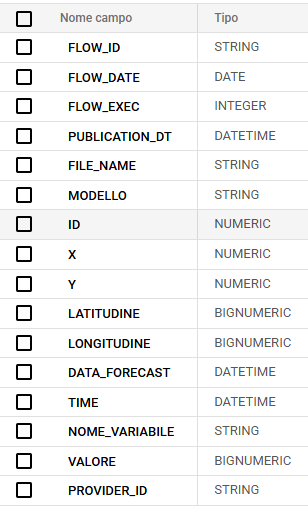

The important ones are:
- <strong>LATITUDINE, LONGITUDINE</strong>: the location in spherical coordinates of the Moloch gridpoint. In D_ANAGRAFICA_METEO_FORECAST it corresponds to the fields MIN_LAT_MOLOCH and MIN_LON_MOLOCH when associated to a Meteomatics/ECOP gridpoint (see below)
- <strong>X, Y</strong>: the native coordinates of the model. Note that they are not aligned to the (<strong>LATITUDINE, LONGITUDINE</strong>) coordinate system, which means that one <strong>X</strong> does not correspond to one <strong>LATITUDINE</strong> and vice-versa. <strong>X</strong> and <strong>Y</strong> are integers.
- <strong>DATA_FORECAST</strong>: the date at which the forecast was initialised. For Meteomatics/ECOP it corresponds to the TRADE_DATE. 
- <strong>TIME</strong>: the date for which the forecast is valid. For Meteomatics/ECOP it corresponds to the VALID_DATE.
- <strong>NOME_VARIABILE</strong>: the parameter name, for which a list is provided in the image below.
- <strong>VALORE</strong>: the value taken by the parameter for the combination of dates and coordinates.

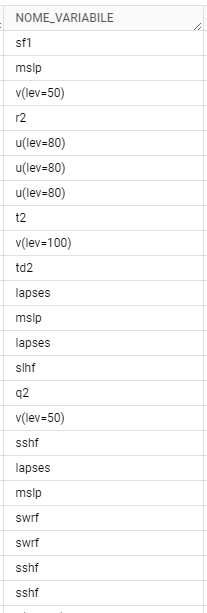

- u,v(level in meters) are the meridional and zonal wind, respectively
- r2 is the relative humidity
- t2 is the temperature at 2m
- td2 is the dew point temperature (the temperature at which the air is saturated in water under gas form, can be useful for heat and comfort indices)
- mslp is the mean sea level pressure, i.e. the pressure at sea level
- sf1 is the snowfall in 1h
- swrf is the short wave radiation flux (incoming solar radiation)
- q2 is the specific humidity
- lapses is the lapse rate, the temperature profile with height


<strong>IMPORTANT NOTE ABOUT GRIDPOINT LOCATIONS:</strong>

On the DP are only Moloch gridpoints picked as "closest to a Meteomatics/ECOP gridpoint", and not the entire grid. This is because the tables have been constructed by colleagues with a point-to-point comparison approach. In the <strong>D_ANAGRAFICA_METEO_FCST</strong>, you will find each entry row with the fields <strong>LAT</strong>, <strong>LON</strong> corresponding to the Meteomatics/ECOP gridpoint coordinates, then another couple <strong>MIN_LAT_MOLOCH</strong>, <strong>MIN_LON_MOLOCH</strong> which correspond to the coordinates of closest Moloch gridpoint. Finally the couple <strong>X_MOLOCH</strong>, <strong>Y_MOLOCH</strong> are the coordinates of that Moloch gridpoint into its native coordinate system.

What if you need more points? Their daily forecasts are available on a national level in a Google bucket in .grib format, of 2GB for each file. Not covered in this notebook.

Gridpoints we used in our analysis:


In [1]:
analysed_gridpoints = {
    'X_MOLOCH': [721, 704, 696, 729, 729, 734, 723, 722, 719, 724, 718, 721, 719, 719, 720, 716],
    'Y_MOLOCH': [295, 311, 312, 278, 295, 298, 325, 278, 274, 276, 274, 270, 276, 271, 270, 274]
}

### Examples of query

Importing libraries

In [2]:
from google.cloud import bigquery # google library for bigquery

# libraries for data manipulation, replace by your favorite ones
import numpy as np 
import pandas as pd 
import datetime as dt 

# libraries for data visualization, replace by your favorite ones
import folium

<strong>TO GET THE GRIDPOINTS IN AN AREA:</strong>

The fastest method is to query the D_ANAGRAFICA_METEO_FCST table for entries with MOLOCH gridpoints associated. 

In [16]:
def get_moloch_gridpoints(min_lat=45.30, max_lat=45.70, min_lon=9.06, max_lon=9.40):
    """
    get the moloch gridpoints available on the DP, for gridpoints in an enclosed area defined by the min and max latitude and longitude
    the default area is approx. the one of the city of Milan

    Parameters
    ----------
    min_lat : float
    max_lat : float
    min_lon : float
    max_lon : float

    Returns
    -------
    return: the dataset with the gridpoints
    """

    project_name = 'a2a-dataplatformgt-pmt-prd'
    client = bigquery.Client(project=project_name)
    
    # Query the grid of gridpoint for which we have the forecast data before 2023
    query = """
        SELECT ANA.*
        FROM `a2a-dataplatformgt-dwh-prd.L2.D_ANAGRAFICA_METEO_FCST` ANA
        WHERE ANA.X_MOLOCH=(SELECT DISTINCT FCST.X, 
            FROM `a2a-dataplatformgt-dwh-prd.L2.F_FORECAST_DATA_ARPAL` FCST
            WHERE ANA.X_MOLOCH=FCST.X AND ANA.Y_MOLOCH=FCST.Y AND FCST.DATA_FORECAST < "2023-01-01T00:00:00" 
            )
        AND ANA.Y_MOLOCH=(SELECT DISTINCT FCST.Y, 
            FROM `a2a-dataplatformgt-dwh-prd.L2.F_FORECAST_DATA_ARPAL` FCST
            WHERE ANA.X_MOLOCH=FCST.X AND ANA.Y_MOLOCH=FCST.Y AND FCST.DATA_FORECAST < "2023-01-01T00:00:00"
            )
        AND ANA.LAT BETWEEN @min_lat AND @max_lat
        AND ANA.LON BETWEEN @min_lon AND @max_lon

        ORDER BY ANA.ID;
        """
    
    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ScalarQueryParameter("min_lat", "FLOAT", min_lat),
            bigquery.ScalarQueryParameter("max_lat", "FLOAT", max_lat),
            bigquery.ScalarQueryParameter("min_lon", "FLOAT", min_lon),
            bigquery.ScalarQueryParameter("max_lon", "FLOAT", max_lon),
            ]
        )
    
    result = client.query(query, job_config=job_config)
    dataset = result.to_dataframe(create_bqstorage_client=False)
    dataset = dataset.astype({'LAT':float, 'LON':float, 'MIN_LAT_MOLOCH':float, 'MIN_LON_MOLOCH':float, 'X_MOLOCH':int, 'Y_MOLOCH':int})

    # some Moloch gridpoints are duplicated, we keep only the first one
    dataset = dataset.drop_duplicates(subset=['X_MOLOCH', 'Y_MOLOCH'], keep='first')

    return dataset    

In [17]:
milan=(45.36, 45.54, 9.03, 9.29)
gridpoints_moloch_in_milan = get_moloch_gridpoints(*milan)

KeyboardInterrupt: 

In [ ]:
print(gridpoints_moloch_in_milan[['LAT', 'LON', 'MIN_LAT_MOLOCH', 'MIN_LON_MOLOCH', 'X_MOLOCH', 'Y_MOLOCH']].reset_index(drop=True))


          LAT       LON  MIN_LAT_MOLOCH  MIN_LON_MOLOCH  X_MOLOCH  Y_MOLOCH
0   45.619000  9.370100       45.620400        9.374582       730       283
1   45.487690  9.107720       45.480948        9.114095       720       270
2   45.487690  9.273910       45.494680        9.273895       721       278
3   45.371060  9.107720       45.368948        9.113871       712       270
4   45.371060  9.273910       45.368680        9.273289       712       278
5   45.604080  9.107720       45.606948        9.114349       729       270
6   45.604080  9.273910       45.606680        9.274436       729       278
7   45.585050  9.269170       45.578680        9.274300       727       278
8   45.462320  9.197350       45.466840        9.193914       719       274
9   45.458670  9.281610       45.452680        9.273692       718       278
10  45.462640  9.158980       45.466900        9.153990       719       272
11  45.506570  9.269790       45.508680        9.273962       722       278
12  45.44700

Here we see well the difference between (LAT, LON) from the Meteomatics/ECOP model, and (MIN_LAT_MOLOCH, MIN_LON_MOLOCH).

In [6]:
def map_gridpoints_moloch(gridpoints):

    # get the min and max lat and lon from the dataset
    min_lat = gridpoints['MIN_LAT_MOLOCH'].min()
    max_lat = gridpoints['MIN_LAT_MOLOCH'].max()
    min_lon = gridpoints['MIN_LON_MOLOCH'].min()
    max_lon = gridpoints['MIN_LON_MOLOCH'].max()

    # Create a map of the gridpoints centered around the midpoint of the latitude and longitude
    map_center = [(min_lat + max_lat) / 2, (min_lon + max_lon) / 2]
    m = folium.Map(location=map_center, zoom_start=10)

    # Add gridpoints to the map
    for idx, row in gridpoints.iterrows():
        folium.CircleMarker(
            location=[row['MIN_LAT_MOLOCH'], row['MIN_LON_MOLOCH']],
            radius=3,
            color='blue',
            fill=True,
            fill_color='blue'
        ).add_to(m)

    return m

Because the density of Meteomatics/ECOP gridpoints is not high in Northern Milan, the same goes for the Moloch gridpoint density.

In [7]:
m = map_gridpoints_moloch(gridpoints_moloch_in_milan)
m

<strong>TO GET THE MOLOCH FORECAST:</strong>

Either by getting all the forecasts from an area available for the list of forecast dates:

In [8]:
def get_moloch_forecast_from_area(var, list_forecast_date, min_lat=45.30, max_lat=45.70, min_lon=9.06, max_lon=9.40):
    """
    get the timeseries of the moloch forecast, for gridpoints in an enclosed area defined by the min and max latitude and longitude

    Parameters
    ----------
    var: the variable to query
    list_forecast_date: the list of trade dates, in the format 'YYYY-MM-DDTHH:MM:SS'
    min_lat : float
    max_lat : float
    min_lon : float
    max_lon : float

    Returns
    -------
    return: the dataset with the forecast
    """

    project_name = 'a2a-dataplatformgt-pmt-prd'
    client = bigquery.Client(project=project_name)
    
    query = """
        SELECT FCST.*
        FROM `a2a-dataplatformgt-dwh-prd.L2.F_FORECAST_DATA_ARPAL` FCST
        WHERE FCST.LATITUDINE BETWEEN @min_lat AND @max_lat
        AND FCST.LONGITUDINE BETWEEN @min_lon AND @max_lon
        AND FCST.NOME_VARIABILE= @var
        AND FCST.DATA_FORECAST in UNNEST(@forecast_dates)
        ORDER BY FCST.TIME;
        """
    
    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ScalarQueryParameter("min_lat", "FLOAT", min_lat),
            bigquery.ScalarQueryParameter("max_lat", "FLOAT", max_lat),
            bigquery.ScalarQueryParameter("min_lon", "FLOAT", min_lon),
            bigquery.ScalarQueryParameter("max_lon", "FLOAT", max_lon),
            bigquery.ArrayQueryParameter("forecast_dates", "DATETIME", list_forecast_date),
            bigquery.ScalarQueryParameter("var", "STRING", var),
            ]
        )
    
    result = client.query(query, job_config=job_config)
    dataset = result.to_dataframe(create_bqstorage_client=False)
    dataset = dataset.astype({'LATITUDINE':float, 'LONGITUDINE':float, 'VALORE':float, 'ID':int, 'X':int, 'Y':int})

    # convert the dates in datetime format and timezone aware
    dataset['TIME'] = dataset['TIME'].astype('datetime64[ns]').dt.tz_localize('UTC')
    dataset['DATA_FORECAST'] = dataset['DATA_FORECAST'].astype('datetime64[ns]').dt.tz_localize('UTC')

    return dataset
    

In [9]:
list_forecast_date = ['2023-01-01T00:00:00', '2023-01-02T00:00:00', '2023-01-03T00:00:00', '2023-01-04T00:00:00', '2023-01-05T00:00:00']
forecast_milan = get_moloch_forecast_from_area('t2', list_forecast_date)


In [10]:
print(forecast_milan.head())

                  FLOW_ID   FLOW_DATE       FLOW_EXEC PUBLICATION_DT  \
0  ARPAL_FORECAST_DATA_00  2022-12-22  91731718059997            NaT   
1  ARPAL_FORECAST_DATA_00  2022-12-22  91731718059997            NaT   
2  ARPAL_FORECAST_DATA_00  2022-12-22  91731718059997            NaT   
3  ARPAL_FORECAST_DATA_00  2022-12-22  91731718059997            NaT   
4  ARPAL_FORECAST_DATA_00  2022-12-22  91731718059997            NaT   

                    FILE_NAME                 MODELLO      ID    X    Y  \
0  molita15sfc_2023010100.csv  molita15sfc_2023010100  904488  719  271   
1  molita15sfc_2023010100.csv  molita15sfc_2023010100  900274  730  283   
2  molita15sfc_2023010100.csv  molita15sfc_2023010100  900405  712  270   
3  molita15sfc_2023010100.csv  molita15sfc_2023010100  904489  721  270   
4  molita15sfc_2023010100.csv  molita15sfc_2023010100  902556  725  282   

   LATITUDINE  LONGITUDINE             DATA_FORECAST  \
0   45.466927     9.134029 2023-01-01 00:00:00+00:00   
1   

In [11]:
 # print the number of distinct lat and lon
print(forecast_milan[['LATITUDINE', 'LONGITUDINE']].drop_duplicates().shape[0])

32


Or by filtering the query with the gridpoints we got before:

In [12]:
def get_moloch_forecast_from_list_of_points(var, list_forecast_date, gridpoints):
    """
    get the timeseries of the moloch forecast, fro gridpoints close to the ifs gridpoints
    
    Parameters
    ----------
    var: the variable to query
    list_forecast_date: the list of trade dates, in the format 'YYYY-MM-DDTHH:MM:SS'
    gridpoints: the dataset with the gridpoints

    Returns
    -------
    return: the dataset with the forecast
    """

    project_name = 'a2a-dataplatformgt-pmt-prd'
    client = bigquery.Client(project=project_name)

    list_xy = [bigquery.StructQueryParameter(None, bigquery.ScalarQueryParameter("x", "FLOAT", x), bigquery.ScalarQueryParameter("y", "FLOAT", y)) for x, y in zip(gridpoints['X_MOLOCH'].to_list(), gridpoints['Y_MOLOCH'].to_list())]
    
    query = """
        SELECT FCST.*
        FROM `a2a-dataplatformgt-dwh-prd.L2.F_FORECAST_DATA_ARPAL` FCST
        WHERE (FCST.X, FCST.Y) IN UNNEST(@list_xy)
            AND FCST.NOME_VARIABILE= @var
            AND FCST.DATA_FORECAST in UNNEST(@forecast_dates)
        ORDER BY FCST.TIME;
        """
    
    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ArrayQueryParameter("list_xy", 
                bigquery.StructQueryParameterType(
                    bigquery.ScalarQueryParameterType(type_="FLOAT", name="x"),
                    bigquery.ScalarQueryParameterType(type_="FLOAT", name="y")
                ), list_xy
              ),
            bigquery.ArrayQueryParameter("forecast_dates", "DATETIME", list_forecast_date),
            bigquery.ScalarQueryParameter("var", "STRING", var),
            ]
        )
    
    result = client.query(query, job_config=job_config)
    dataset = result.to_dataframe(create_bqstorage_client=False)
    dataset = dataset.astype({'LATITUDINE':float, 'LONGITUDINE':float, 'VALORE':float, 'ID':int, 'X':int, 'Y':int})

    # convert the dates in datetime format and timezone aware
    dataset['TIME'] = dataset['TIME'].astype('datetime64[ns]').dt.tz_localize('UTC')
    dataset['DATA_FORECAST'] = dataset['DATA_FORECAST'].astype('datetime64[ns]').dt.tz_localize('UTC')

    return dataset
    

In [13]:
forecast_milan_2 = get_moloch_forecast_from_list_of_points('t2', list_forecast_date, gridpoints_moloch_in_milan)

In [14]:
print(forecast_milan_2.head())

                  FLOW_ID   FLOW_DATE       FLOW_EXEC PUBLICATION_DT  \
0  ARPAL_FORECAST_DATA_00  2022-12-22  91731718059997            NaT   
1  ARPAL_FORECAST_DATA_00  2022-12-22  91731718059997            NaT   
2  ARPAL_FORECAST_DATA_00  2022-12-22  91731718059997            NaT   
3  ARPAL_FORECAST_DATA_00  2022-12-22  91731718059997            NaT   
4  ARPAL_FORECAST_DATA_00  2022-12-22  91731718059997            NaT   

                    FILE_NAME                 MODELLO      ID    X    Y  \
0  molita15sfc_2023010100.csv  molita15sfc_2023010100  904488  719  271   
1  molita15sfc_2023010100.csv  molita15sfc_2023010100  900274  730  283   
2  molita15sfc_2023010100.csv  molita15sfc_2023010100  900405  712  270   
3  molita15sfc_2023010100.csv  molita15sfc_2023010100  904489  721  270   
4  molita15sfc_2023010100.csv  molita15sfc_2023010100  902556  725  282   

   LATITUDINE  LONGITUDINE             DATA_FORECAST  \
0   45.466927     9.134029 2023-01-01 00:00:00+00:00   
1   

In [15]:
# print the number of distinct lat and lon
print(forecast_milan_2[['LATITUDINE', 'LONGITUDINE']].drop_duplicates().shape[0])

32
